> ## ⚠️ Running this notebook in the Docker workshop image?
>
> These notebooks were written assuming a **local install with a display**
> — every cell with `MetalGUI(design)` or `gui.screenshot()` requires Qt
> with a working X server, which the Docker image does not have.
>
> **In Docker, do this instead:**
> - Replace `gui = MetalGUI(design)` with nothing (skip the GUI cell).
> - Replace `gui.rebuild(); gui.screenshot()` with `qm.view(design)` — it
>   returns a `matplotlib.figure.Figure` and renders inline in JupyterLab,
>   no Qt required. Same code-path the chip exports use.
> - The chip design, simulation, and analysis cells are unchanged.
>
> If you want the full Qt GUI, run **outside** Docker: `pip install
> 'quantum-metal[full]'` on your local machine, open this notebook in
> Jupyter, and `MetalGUI(design)` will work.

# Coupling two transmons

In [1]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True
%matplotlib inline
%config Completer.use_jedi = False
%config InlineBackend.figure_format = 'svg'


In [2]:
from qiskit_metal.analyses.hamiltonian.transmon_charge_basis import Hcpb
from qiskit_metal.analyses.hamiltonian.transmon_CPB_analytic import Hcpb_analytic
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


import scqubits as scq
from scqubits import HilbertSpace, InteractionTerm, ParameterSweep

import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings
import pyEPR as epr
from qiskit_metal.qlibrary.couplers.tunable_coupler_01 import TunableCoupler01

from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
import qiskit_metal.analyses.quantization.lumped_capacitive as lumped_cap
import qiskit_metal.analyses.quantization.lumped_oscillator_model as lom_func
from collections import OrderedDict
# from squadds.components.qubits import TransmonCross
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
# from squadds.components.airbridge.airbridge_generator import AirbridgeGenerator
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee

import schemdraw
import schemdraw.elements as elm
import schemdraw.flow as flow

import numpy as np
import matplotlib.pyplot as plt
from SQDMetal.Comps.Xmon import Xmon
from SQDMetal.Comps.Junctions import JunctionDolanPinStretch
from SQDMetal.Comps.Capacitors import CapacitorProngPin
from SQDMetal.Utilities.Materials import MaterialInterface

# Auto-discover the palace executable — works inside the workshop's docker
# image (palace is on PATH via spack) and on local installs where palace is
# in $PATH. If you have it elsewhere, replace this with the explicit path.
import shutil
path_to_palace = shutil.which("palace")
if path_to_palace is None:
    raise RuntimeError(
        "palace executable not found on PATH. "
        "If using the workshop Docker image you should not hit this — "
        "check 'docker compose exec dev which palace'. "
        "If running locally, set path_to_palace='/your/path/to/palace' here."
    )
hbar = 6.62607015e-034 / (2 * np.pi)  # J.s
flux_0 = hbar * np.pi / 1.6e-19   # J.s / phi_0

07:45PM 02s WARNING [_maybe_warn_import_rename]: [FutureWarning] A future major release of quantum-metal (target v0.8 / v1.0) will rename the Python import path from `qiskit_metal` to `quantum_metal` to match the PyPI package name. Plan to update your imports ahead of that release. See ROADMAP.md and the README rebrand notice. Suppress this warning with QISKIT_METAL_SUPPRESS_RENAME_WARNING=1.


Here, we will discuss one of most basic form of coupling between two qubits. In this case, we have two xmons with a capacitive coupling mediated by a bus. A similar form of coupling can be established by bringing two qubit pads close to each other.

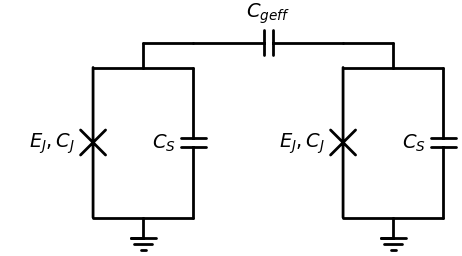

In [3]:
# Create a new drawing
d = schemdraw.Drawing()

# --- Define Nodes ---
bottom_node = (0,0) # Common ground node


# Drawing the qubit circuit
charge_node = d.here
d += elm.Line().down().length(0.5)
junction_node = d.here
d += elm.Line().left().length(1)
d += elm.Josephson().down().label('$E_J, C_J$')
d += elm.Line().right().length(1)
d += elm.Line().right().length(1).at(junction_node)
d += elm.Capacitor().down().label('$C_S$')
d += elm.Line().left().length(1)
d += elm.Ground()
d += elm.Line().right().length(1).at(charge_node)
d += elm.Capacitor().right().label('$C_{geff}$')
d += elm.Line().right().length(1)
# Drawing the resonator circuit
d += elm.Line().down().length(0.5)
resonator_node = d.here
d += elm.Line().left().length(1)
d += elm.Josephson().down().label('$E_J, C_J$')
d += elm.Line().right().length(1)
d += elm.Line().right().length(1).at(resonator_node)
d += elm.Capacitor().down().label('$C_S$')
d += elm.Line().left().length(1)
d += elm.Ground()
d.draw()

The total Hamiltonian of this system can be simplified as:
$$
H = H_1 + H_2 + H_{int}
$$,
which is sum of both qubit energies and the interaction energy between two sides of the circuit, $H_{int}$. The interaction energy is in the form of $H_{int} = C_g V_1 V_2$, where $C_g$ is coupling capacitance and $V_i$ is voltage operator. 

Using circuit quantization methods, we can get this interaction Hamiltonian as:
$$
H_{int} = 4e^2 \frac{C_g}{C_1 C_2}\hat{n}_1\hat{n}_2
$$

In this section, we will first find the effective coupling capacitance $C_g$ and calculate the coupling strength between two qubits.

In [ ]:
design = designs.DesignPlanar({}, overwrite_enabled=True)
design.delete_all_components()
gui = MetalGUI(design)


# Set up chip dimensions 
design.chips.main.size.size_x = '2mm'
design.chips.main.size.size_y = '2mm'
design.chips.main.size.size_z = '-280um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '0mm'

# Resonator and feedline gap width (W) and center conductor width (S) 
design.variables['cpw_width'] = '10 um' #S
design.variables['cpw_gap'] = '40 um' #W 
# Lets create the qubit with a junction and a claw

## Qubit
xmon1 = Xmon(design, 'Q1', options=Dict(pos_x = '-0.18mm', pos_y='0',
                                    vBar_width='50um', hBar_width='50um', vBar_gap=f'{50}um', hBar_gap=f'{50}um',
                                    cross_width=f'{320}um', cross_height=f'{320}um',
                                    gap_up='40um', gap_left='40um', gap_right='40um', gap_down='40um'))

# Junction
JunctionDolanPinStretch(design, 'junction1', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q1',pin='down')),
                                                         dist_extend='40um',
                                                         layer=2,
                                                         finger_width='0.4um', t_pad_size='0.385um',
                                                         squid_width='5.4um', prong_width='0.9um'))



xmon2 = Xmon(design, 'Q2', options=Dict(pos_x = '0.18mm', pos_y='0',
                                    vBar_width='50um', hBar_width='50um', vBar_gap=f'{50}um', hBar_gap=f'{50}um',
                                    cross_width=f'{320}um', cross_height=f'{320}um',
                                    gap_up='40um', gap_left='40um', gap_right='40um', gap_down='40um'))

# Junction
JunctionDolanPinStretch(design, 'junction2', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q2',pin='down')),
                                                         dist_extend='40um',
                                                         layer=2,
                                                         finger_width='0.4um', t_pad_size='0.385um',
                                                         squid_width='5.4um', prong_width='0.9um'))



gui.rebuild()
gui.autoscale()
gui.screenshot('sims/qubit-qubit.png')

07:45PM 15s WARNING [_qt_message_handler]: WARNING: could not connect to display  (No context available from Qt)
Python Traceback (most recent call last):
  File "/home/ubuntu/qdw-workshop-materials/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3170, in run_cell
    result = self._run_cell(
  File "/home/ubuntu/qdw-workshop-materials/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3225, in _run_cell
    result = runner(coro)
  File "/home/ubuntu/qdw-workshop-materials/.venv/lib/python3.12/site-packages/IPython/core/async_helpers.py", line 128, in _pseudo_sync_runner
    coro.send(None)
  File "/home/ubuntu/qdw-workshop-materials/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3447, in run_cell_async
    has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
  File "/home/ubuntu/qdw-workshop-materials/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3688, in run_ast_node

In [1]:
from SQDMetal.PALACE.Capacitance_Simulation import PALACE_Capacitance_Simulation

user_defined_options = {
                "mesh_refinement": 0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "solver_order": 1,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solver_tol": 1.0e-8,                              #error residual tolerance for iterative solver
                "solver_maxits": 500,                              #number of solver iterations
                "mesh_max": 120e-6,                                #maxiumum element size for the mesh in mm
                "mesh_sampling": 150,                              #number of points to mesh along a geometry
                "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                "num_cpus": 10,                                      #number of CPU cores to use for simulation
                "palace_dir":path_to_palace
                }
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["PMIX_MCA_gds"]="hash"

import gmsh
gmsh.initialize()


os.makedirs('sims', exist_ok=True)
#Creat the Palace Eigenmode simulation
cap_sim = PALACE_Capacitance_Simulation(name = 'transmon_cross_cap_sim',                                 #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "sims/",            #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        view_design_gmsh_gui = False,                               #view design in GMSH gui
                                        create_files = True,
                                        )                                        #create mesh, config and HPC batch files

cap_sim.add_metallic(1, threshold=1e-10, fuse_threshold=1e-10)
cap_sim.add_ground_plane(threshold=1e-10)

for ii in ["Q1", "Q2"]:
    bounds = design.components[ii].qgeometry_bounds()
#Fine-mesh the transmon cross qubit region
    cap_sim.fine_mesh_in_rectangle(bounds[0]*1e-3, bounds[1]*1e-3, bounds[2]*1e-3, bounds[3]*1e-3, mesh_sampling=100, mesh_min=1e-6, mesh_max=50e-3)

cap_sim.prepare_simulation()
cap_sim.display_conductor_indices()





07:45PM 38s WARNING [_maybe_warn_import_rename]: [FutureWarning] A future major release of quantum-metal (target v0.8 / v1.0) will rename the Python import path from `qiskit_metal` to `quantum_metal` to match the PyPI package name. Plan to update your imports ahead of that release. See ROADMAP.md and the README rebrand notice. Suppress this warning with QISKIT_METAL_SUPPRESS_RENAME_WARNING=1.


NameError: name 'path_to_palace' is not defined

In [ ]:
from SQDMetal.PALACE.Utilities.GMSH_Navigator import GMSH_Navigator

# Let's look how the mesh looks in GMSH
# Open the GMSH GUI

gmsh_nav = GMSH_Navigator(cap_sim.path_mesh)
gmsh_nav.open_GUI()

In [22]:
cap_matrix = cap_sim.run()

>> /opt/homebrew/bin/mpirun -n 10 /Users/mcansarihan/qubit_design/palace/build/bin/palace-arm64.bin transmon_cross_cap_sim.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)
Git changeset ID: v0.13.0-454-gcd4d7b78
Running with 10 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 3495 duplicate vertices for interior boundaries in the mesh
Added 7606 duplicate boundary elements for interior boundaries in the mesh
Added 440 boundary elements for material interfaces to the mesh
Finished partitioning mesh into 10 subdomains

Characteristic length and time scales:
 L₀ = 2.400e-03 m, t₀ = 8.006e-03 ns

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-1.200e-03, -1.200

In [ ]:
cdf = pd.DataFrame(cap_matrix*1e15)

# get rid of the first column
cdf = cdf.iloc[:, 1:]

# assigning the columns and indices based on our geometry
cdf.columns = ["ground", "xmon2","xmon1"]
cdf.index = ["ground", "xmon2", "xmon1"]
cdf

,ground,xmon2,xmon1
ground,1787.113720,-69.843694,-69.632651
xmon2,-69.843694,97.010462,-4.220718
xmon1,-69.632651,-4.220718,96.804766


: 

Based on the capacitance between two qubits, we can estimate our unitless coupling efficiency: $k_{q1q2} = C_g/\sqrt{C_1C_2}$

In [ ]:
coupling_eff = np.abs(cdf.loc["xmon2", "xmon1"]/np.sqrt(cdf.loc["xmon1","xmon1"]*cdf.loc["xmon2","xmon2"]))
print(f"Coupling Efficiency = {coupling_eff*100:.2f}%")

Coupling Efficiency = 4.25%


We will use our approximation to estimate the coupling strength between the two qubits.

$$
g = k_{q1q2} \sqrt{f_{q1} f_{q2}}/2
$$

In [ ]:
frequency_q1 = 4e9
frequency_q2 = 4e9

g = coupling_eff * frequency_q / 2 
print(f"Coupling Strength = {g*1000:.2f} MHz")

Coupling Strength = 104.27 MHz


## Two transmons coupled via bus

Here, we have added a bus waveguide to couple distant qubits to each other. We will see how the coupling changes with the distance between the qubits.

In [ ]:

design = designs.DesignPlanar({}, overwrite_enabled=True)
design.delete_all_components()
gui = MetalGUI(design)


# Set up chip dimensions 
design.chips.main.size.size_x = '2mm'
design.chips.main.size.size_y = '2mm'
design.chips.main.size.size_z = '-280um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '0mm'

# Resonator and feedline gap width (W) and center conductor width (S) 
design.variables['cpw_width'] = '10 um' #S
design.variables['cpw_gap'] = '40 um' #W 
# Lets create the qubit with a junction and a claw

## Qubit
xmon1 = Xmon(design, 'Q1', options=Dict(pos_x = '-0.4mm', pos_y='0',
                                    vBar_width='50um', hBar_width='50um', vBar_gap=f'{50}um', hBar_gap=f'{50}um',
                                    cross_width=f'{320}um', cross_height=f'{320}um',
                                    gap_up='40um', gap_left='40um', gap_right='40um', gap_down='40um'))

# Junction
JunctionDolanPinStretch(design, 'junction1', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q1',pin='down')),
                                                         dist_extend='40um',
                                                         layer=2,
                                                         finger_width='0.4um', t_pad_size='0.385um',
                                                         squid_width='5.4um', prong_width='0.9um'))


# # Claw
CapacitorProngPin(design, 'claw1', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q1',pin='right')),
                                                prong_width='10um', prong_length='20um', pin_gap_side='10um',
                                                gap_side='20um', pad_thickness='20um',
                                                gap_front='20um', gap_back='20um', trace_width='10um'))
xmon2 = Xmon(design, 'Q2', options=Dict(pos_x = '0.4mm', pos_y='0',
                                    vBar_width='50um', hBar_width='50um', vBar_gap=f'{50}um', hBar_gap=f'{50}um',
                                    cross_width=f'{320}um', cross_height=f'{320}um',
                                    gap_up='40um', gap_left='40um', gap_right='40um', gap_down='40um'))

# Junction
JunctionDolanPinStretch(design, 'junction2', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q2',pin='down')),
                                                         dist_extend='40um',
                                                         layer=2,
                                                         finger_width='0.4um', t_pad_size='0.385um',
                                                         squid_width='5.4um', prong_width='0.9um'))


# # Claw
CapacitorProngPin(design, 'claw2', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q2',pin='left')),
                                                prong_width='10um', prong_length='20um', pin_gap_side='10um',
                                                gap_side='20um', pad_thickness='20um',
                                                gap_front='20um', gap_back='20um', trace_width='10um'))


coupler = RouteStraight(design, 'coupler', Dict(hfss_wire_bonds = True,
        pin_inputs=Dict(
            start_pin=Dict(component='claw1', pin='a'),
            end_pin=Dict(component='claw2', pin='a')), ))


gui.rebuild()
gui.autoscale()

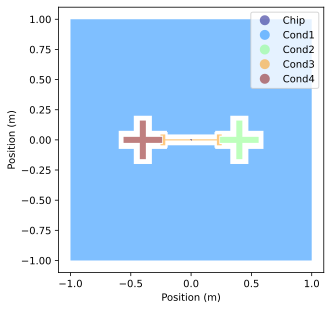

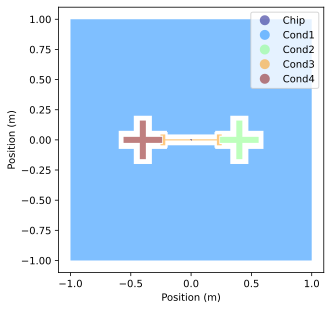

In [ ]:
from SQDMetal.PALACE.Capacitance_Simulation import PALACE_Capacitance_Simulation

user_defined_options = {
                "mesh_refinement": 0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "solver_order": 1,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solver_tol": 1.0e-8,                              #error residual tolerance for iterative solver
                "solver_maxits": 500,                              #number of solver iterations
                "mesh_max": 120e-6,                                #maxiumum element size for the mesh in mm
                "mesh_sampling": 150,                              #number of points to mesh along a geometry
                "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                "num_cpus": 10,                                      #number of CPU cores to use for simulation
                "palace_dir":path_to_palace
                }
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["PMIX_MCA_gds"]="hash"

import gmsh
gmsh.initialize()


os.makedirs('sims', exist_ok=True)
#Creat the Palace Eigenmode simulation
cap_sim = PALACE_Capacitance_Simulation(name = 'transmon_cross_cap_sim',                                 #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "sims/",            #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        view_design_gmsh_gui = False,                               #view design in GMSH gui
                                        create_files = True,
                                        )                                        #create mesh, config and HPC batch files

cap_sim.add_metallic(1, threshold=1e-10, fuse_threshold=1e-10)
cap_sim.add_ground_plane(threshold=1e-10)

for ii in ["Q1", "Q2"]:
    bounds = design.components[ii].qgeometry_bounds()
#Fine-mesh the transmon cross qubit region
    cap_sim.fine_mesh_in_rectangle(bounds[0]*1e-3, bounds[1]*1e-3, bounds[2]*1e-3, bounds[3]*1e-3, mesh_sampling=100, mesh_min=1e-6, mesh_max=50e-3)

cap_sim.prepare_simulation()
cap_sim.display_conductor_indices()





In [ ]:
cap_matrix = cap_sim.run()

>> /opt/homebrew/bin/mpirun -n 10 /Users/mcansarihan/qubit_design/palace/build/bin/palace-arm64.bin transmon_cross_cap_sim.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)
Git changeset ID: v0.13.0-454-gcd4d7b78
Running with 10 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 118 elements in 2 iterations of local bisection for under-resolved interior boundaries
Added 4152 duplicate vertices for interior boundaries in the mesh
Added 9074 duplicate boundary elements for interior boundaries in the mesh
Added 440 boundary elements for material interfaces to the mesh
Finished partitioning mesh into 10 subdomains

Characteristic length and time scales:
 L₀ = 2.400e-03 m, t₀ = 8.006

In [ ]:
cdf = pd.DataFrame(cap_matrix*1e15)

# get rid of the first column
cdf = cdf.iloc[:, 1:]

# assigning the columns and indices based on our geometry
cdf.columns = ["ground", "xmon2","bus","xmon1"]
cdf.index = ["ground", "xmon2","bus", "xmon1"]
cdf = cdf.reindex(index=["bus", "ground",  "xmon1","xmon2"], columns=["bus","ground",  "xmon1","xmon2"])
cdf

,bus,ground,xmon1,xmon2
bus,155.953757,-108.697917,-17.702593,-17.406808
ground,-108.697917,1880.397626,-67.103289,-67.294002
xmon1,-17.702593,-67.103289,106.806045,-0.004817
xmon2,-17.406808,-67.294002,-0.004817,106.692196


In [ ]:
coupling_eff = (cdf.loc["bus", "xmon1"]/np.sqrt(cdf.loc["xmon1","xmon1"]*cdf.loc["bus","bus"])) * (cdf.loc["bus", "xmon2"]/np.sqrt(cdf.loc["xmon2","xmon2"]*cdf.loc["bus","bus"]))
print(f"Coupling Efficiency = {coupling_eff*100:.2f} %")

Coupling Efficiency = 1.85 %


We found our unitless coupling efficiency by multiplying the two coupling efficiencies between the bus and the two qubits. We will use our approximation to estimate the coupling strength between the two qubits.

$$
g = k_{q1q2} \sqrt{f_{q1} f_{q2}}/2
$$

In [ ]:
frequency_q1 = 4e9
frequency_q2 = 4e9

g = coupling_eff * np.sqrt(frequency_q1 * frequency_q2) / 2 
print(f"Coupling Strength = {g*1000:.2f} MHz")

Coupling Strength = 45.39 MHz


Using the second quantization, we can represent the interaction Hamiltonian as:

$H_{int} = g (a_1-a_1^†) (a_2-a_2^†)$
where $a_1$ and $a_2$ are the annihilation operators for the two qubits. 
If we truncate the higher energy levels and restrict our qubits to Pauli basis (only 0-1 levels), we can reduce this Hamiltonian to:
$$
H = \frac{1}{2} \omega_{q1}\sigma_{z1} + \frac{1}{2}  \omega_{q2}\sigma_{z2} + g\sigma_{y1}\sigma_{y2}
$$
We see that the resulting coupling term is on y-axis, which is arbitrary and can also be identified by x axis. This indicates the presence of an exchange interaction between the qubits and called as transverse coupling. Transverse coupling can be used to perform two-qubit entangling gates such as SWAP family of gates.

Of course, this holds only when the system is truncated to the first two energy levels and ignores the presence of higher order states and couplings. In reality, two qubits have a mix of both transverse and longitudinal couplings(in z-basis) during the operation.

Another caveat is, these kind of static capacitive interactions are always on, which poses a problem to coherence of the qubits when they are idle. In order to overcome these challenges, state-of-the-art implementations utilize tunable coupling schemes, where a second coupling channel with tunable coupling strength is used to negate the static capacitive coupling between two qubits.

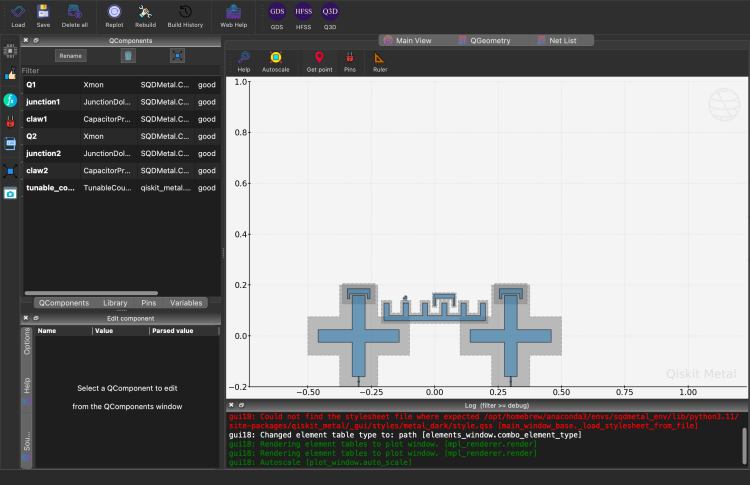

In [ ]:
# Tunable coupler device example
design = designs.DesignPlanar({}, overwrite_enabled=True)
design.delete_all_components()
gui = MetalGUI(design)


# Set up chip dimensions 
design.chips.main.size.size_x = '2mm'
design.chips.main.size.size_y = '2mm'
design.chips.main.size.size_z = '-280um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '0mm'

# Resonator and feedline gap width (W) and center conductor width (S) 
design.variables['cpw_width'] = '10 um' #S
design.variables['cpw_gap'] = '40 um' #W 
# Lets create the qubit with a junction and a claw

## Qubit
xmon1 = Xmon(design, 'Q1', options=Dict(pos_x = '-0.3mm', pos_y='0',
                                    vBar_width='50um', hBar_width='50um', vBar_gap=f'{50}um', hBar_gap=f'{50}um',
                                    cross_width=f'{320}um', cross_height=f'{320}um',
                                    gap_up='40um', gap_left='40um', gap_right='40um', gap_down='40um'))

# Junction
JunctionDolanPinStretch(design, 'junction1', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q1',pin='down')),
                                                         dist_extend='40um',
                                                         layer=2,
                                                         finger_width='0.4um', t_pad_size='0.385um',
                                                         squid_width='5.4um', prong_width='0.9um'))


# # Claw
CapacitorProngPin(design, 'claw1', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q1',pin='up')),
                                                prong_width='10um', prong_length='20um', pin_gap_side='10um',
                                                gap_side='20um', pad_thickness='20um',
                                                gap_front='20um', gap_back='20um', trace_width='10um'))
xmon2 = Xmon(design, 'Q2', options=Dict(pos_x = '0.3mm', pos_y='0',
                                    vBar_width='50um', hBar_width='50um', vBar_gap=f'{50}um', hBar_gap=f'{50}um',
                                    cross_width=f'{320}um', cross_height=f'{320}um',
                                    gap_up='40um', gap_left='40um', gap_right='40um', gap_down='40um'))

# Junction
JunctionDolanPinStretch(design, 'junction2', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q2',pin='down')),
                                                         dist_extend='40um',
                                                         layer=2,
                                                         finger_width='0.4um', t_pad_size='0.385um',
                                                         squid_width='5.4um', prong_width='0.9um'))


# # Claw
CapacitorProngPin(design, 'claw2', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'Q2',pin='up')),
                                                prong_width='10um', prong_length='20um', pin_gap_side='10um',
                                                gap_side='20um', pad_thickness='20um',
                                                gap_front='20um', gap_back='20um', trace_width='10um'))

# Tunable Coupler
coupler = TunableCoupler01(design, 'tunable_coupler', options=Dict(pos_x='0mm', pos_y='0.07mm', ))

gui.rebuild()
gui.autoscale()
gui.screenshot('sims/tunable_coupler.png')